In [41]:
from jupyterthemes import get_themes
import jupyterthemes as jt
from jupyterthemes.stylefx import set_nb_theme

set_nb_theme('onedork')

# Topology Discovery Benchmark – Tutorial Notebook

This notebook walks you through how to interact with the **Topology Discovery API** end-to-end:

1. Create a small **mock grid** and corresponding **historical data** and insert them via the API.
2. Use the **topology discovery endpoints** to:
   - Download training data with labelled connections
   - Download test data without connections
   - Build and submit a topology **guess** for each grid
   - Retrieve a **score** for your guess

The goal is to provide a minimal, reproducible example that you can adapt to your own grids, models and workflows.

## 0. Environment and prerequisites

Before running this notebook, you should have:

- A running instance of the **Topology Discovery API** (locally or remote).
- The correct `BASE_URL` and path prefixes configured in the code cells below.
- Network access from this notebook environment to the API endpoint.

The helper functions defined in the next cells (e.g. `check_response`, `safe_get_json`) are thin wrappers around `requests` that:
- Simplify HTTP calls
- Standardise error handling
- Return already parsed JSON where appropriate

You do **not** need to modify these helpers for normal use; they are here to keep the rest of the tutorial cleaner.

## Auxiliary Functions and Variable Declaration

In [10]:
import requests
import pandas as pd
from collections import defaultdict
from pathlib import Path
import json
import numpy as np
import topologytest as tp

BASE_URL = "http://localhost:8080"           # adapt if API initialized in a different port
TOPOLOGY_PREFIX = "/topology_discovery_benchmark"


def check_response(resp: requests.Response):
    """Raise for HTTP errors and return parsed JSON or raw text."""
    try:
        resp.raise_for_status()
    except requests.HTTPError as e:
        try:
            print("Error payload:", resp.json())
        except Exception:
            print("Raw response:", resp.text)
        raise e
    try:
        return resp.json()
    except Exception:
        return resp.text

# 0. Create and insert test grid and historical

To validate our API and test the endpoints, we will now write code that generates mock grid definitions and corresponding mock historical measurements, and inserts this data into the PostgreSQL database. This seeded data will allow us to exercise the main read endpoints without depending on real-world measurements.

## 0.1 Creating a mock grid

To make this tutorial self-contained, we start by defining a **small test grid** directly in Python.

- The grid has a single `grid_id` (`grid_001`).
- It contains several nodes, some with geographic coordinates and some without.
- We will send this JSON to the API using the `/grid` endpoint so that the backend knows about our test network.

In a real scenario, you would generate this JSON from your own network model, but the structure would be the same.

In [3]:
test_grid = {
  "grid_id": "grid_001",
  "nodes": [
    {
      "node_id": "PT",
      "coord_lat": 38.7223,
      "coord_lon": -9.1393,
      "coord_error": 5
    },
    {
      "node_id": "NODE000000002",
      "coord_lat": 38.7260,
      "coord_lon": -9.1400,
      "coord_error": None
    },
    {
      "node_id": "NODE000000003",
      "coord_lat": None,
      "coord_lon": None,
      "coord_error": None
    },
    {
      "node_id": "NODE000000004",
      "coord_lat": 38.7270,
      "coord_lon": -9.1410,
      "coord_error": 7
    },
    {
      "node_id": "NODE000000005",
      "coord_lat": 38.7280,
      "coord_lon": -9.1420,
      "coord_error": None
    },
    {
      "node_id": "NODE000000006",
      "coord_lat": None,
      "coord_lon": None,
      "coord_error": None
    },
    {
      "node_id": "NODE000000007",
      "coord_lat": 38.7295,
      "coord_lon": -9.1435,
      "coord_error": 10
    },
    {
      "node_id": "NODE000000008",
      "coord_lat": 38.7305,
      "coord_lon": -9.1440,
      "coord_error": None
    },
    {
      "node_id": "NODE000000009",
      "coord_lat": None,
      "coord_lon": None,
      "coord_error": None
    },
    {
      "node_id": "NODE000000010",
      "coord_lat": 38.7315,
      "coord_lon": -9.1450,
      "coord_error": 12
    }
  ],
  "connections": [
    {
      "connection_id": "LineUID000001",
      "from_node_id": "PT",
      "to_node_id": "NODE000000002",
      "length": 120.5,
      "cable_id": "TypeLine00001"
    },
    {
      "connection_id": "LineUID000002",
      "from_node_id": "NODE000000002",
      "to_node_id": "NODE000000003",
      "length": 85.0,
      "cable_id": "TypeLine00002"
    },
    {
      "connection_id": "LineUID000003",
      "from_node_id": "NODE000000003",
      "to_node_id": "NODE000000004",
      "length": 60.0,
      "cable_id": "TypeLine00001"
    },
    {
      "connection_id": "LineUID000004",
      "from_node_id": "NODE000000004",
      "to_node_id": "NODE000000005",
      "length": 45.0,
      "cable_id": "TypeLine00002"
    },
    {
      "connection_id": "LineUID000005",
      "from_node_id": "NODE000000005",
      "to_node_id": "NODE000000006",
      "length": 70.0,
      "cable_id": "TypeLine00001"
    },
    {
      "connection_id": "LineUID000006",
      "from_node_id": "NODE000000005",
      "to_node_id": "NODE000000007",
      "length": 55.0,
      "cable_id": "TypeLine00002"
    },
    {
      "connection_id": "LineUID000007",
      "from_node_id": "NODE000000002",
      "to_node_id": "NODE000000008",
      "length": 40.0,
      "cable_id": "TypeLine00001"
    },
    {
      "connection_id": "LineUID000008",
      "from_node_id": "NODE000000008",
      "to_node_id": "NODE000000009",
      "length": 30.0,
      "cable_id": "TypeLine00002"
    },
    {
      "connection_id": "LineUID000009",
      "from_node_id": "NODE000000009",
      "to_node_id": "NODE000000010",
      "length": 65.0,
      "cable_id": "TypeLine00001"
    },
    {
      "connection_id": "LineUID000010",
      "from_node_id": "NODE000000003",
      "to_node_id": "NODE000000007",
      "length": 50.0,
      "cable_id": "TypeLine00002"
    }
  ],
  "cables": [
    {
      "cable_id": "TypeLine00001",
      "r_imp_real": 0.123,
      "r_imp_imag": 0.045,
      "s_imp_real": 0.120,
      "s_imp_imag": 0.044,
      "t_imp_real": 0.119,
      "t_imp_imag": 0.043,
      "r_nom_curr": 150.0,
      "s_nom_curr": 150.0,
      "t_nom_curr": 150.0
    },
    {
      "cable_id": "TypeLine00002",
      "r_imp_real": 0.200,
      "r_imp_imag": 0.060,
      "s_imp_real": 0.198,
      "s_imp_imag": 0.059,
      "t_imp_real": 0.197,
      "t_imp_imag": 0.058,
      "r_nom_curr": 100.0,
      "s_nom_curr": 100.0,
      "t_nom_curr": 100.0
    }
  ]
}

# Save to file
with open("grid_data.json", "w", encoding="utf-8") as f:
    json.dump(test_grid, f, ensure_ascii=False, indent=2)

## 0.2 Creating mock historical measurements

Next, we define **mock historical time-series data** for the same grid:

- Each block is associated with a specific `node_id`.
- For each node, we store multiple time-stamped measurements, including:
  - `power_active` / `power_reactive`
  - `voltage_magnitude` / `voltage_angle`
  - `phase` (R, S, T), which in real data might be unknown or inferred

This dataset is intentionally small, but it mimics the structure expected by the `/historical` endpoint.  
You can later replace this block with real measurements exported from your SCADA, AMI or simulation tools.

In [4]:
test_historical = {
  "grid_id": "grid_001",
  "historical": [
    {
      "node_id": "PT",
      "measurements": [
        {
          "datetime": "2025-01-15T10:30:00Z",
          "phase": "R",
          "power_active": 125.3,
          "power_reactive": 46.1,
          "voltage_magnitude": 230.2,
          "voltage_angle": -5.1
        },
        {
          "datetime": "2025-01-15T10:31:00Z",
          "phase": "S",
          "power_active": 123.8,
          "power_reactive": 45.5,
          "voltage_magnitude": 230.0,
          "voltage_angle": -5.0
        },
        {
          "datetime": "2025-01-15T10:32:00Z",
          "phase": "T",
          "power_active": 121.9,
          "power_reactive": 44.7,
          "voltage_magnitude": 229.7,
          "voltage_angle": -4.9
        },
        {
          "datetime": "2025-01-15T10:33:00Z",
          "phase": "R",
          "power_active": 120.9,
          "power_reactive": 44.2,
          "voltage_magnitude": 229.5,
          "voltage_angle": -4.8
        },
        {
          "datetime": "2025-01-15T10:34:00Z",
          "phase": "S",
          "power_active": 119.9,
          "power_reactive": 43.7,
          "voltage_magnitude": 229.3,
          "voltage_angle": -4.7
        },
        {
          "datetime": "2025-01-15T10:35:00Z",
          "phase": "T",
          "power_active": 118.9,
          "power_reactive": 43.2,
          "voltage_magnitude": 229.1,
          "voltage_angle": -4.6
        },
        {
          "datetime": "2025-01-15T10:36:00Z",
          "phase": "R",
          "power_active": 117.9,
          "power_reactive": 42.7,
          "voltage_magnitude": 228.9,
          "voltage_angle": -4.5
        },
        {
          "datetime": "2025-01-15T10:37:00Z",
          "phase": "S",
          "power_active": 116.9,
          "power_reactive": 42.2,
          "voltage_magnitude": 228.7,
          "voltage_angle": -4.4
        }
      ]
    },
    {
      "node_id": "NODE000000002",
      "measurements": [
        {
          "datetime": "2025-01-15T10:30:00Z",
          "phase": "R",
          "power_active": 110.4,
          "power_reactive": 39.2,
          "voltage_magnitude": 229.8,
          "voltage_angle": -5.3
        },
        {
          "datetime": "2025-01-15T10:31:00Z",
          "phase": "S",
          "power_active": 108.9,
          "power_reactive": 38.6,
          "voltage_magnitude": 229.4,
          "voltage_angle": -5.1
        },
        {
          "datetime": "2025-01-15T10:32:00Z",
          "phase": "T",
          "power_active": 107.1,
          "power_reactive": 37.9,
          "voltage_magnitude": 229.1,
          "voltage_angle": -5.0
        },
        {
          "datetime": "2025-01-15T10:33:00Z",
          "phase": "R",
          "power_active": 106.1,
          "power_reactive": 37.4,
          "voltage_magnitude": 228.9,
          "voltage_angle": -4.9
        },
        {
          "datetime": "2025-01-15T10:34:00Z",
          "phase": "S",
          "power_active": 105.1,
          "power_reactive": 36.9,
          "voltage_magnitude": 228.7,
          "voltage_angle": -4.8
        },
        {
          "datetime": "2025-01-15T10:35:00Z",
          "phase": "T",
          "power_active": 104.1,
          "power_reactive": 36.4,
          "voltage_magnitude": 228.5,
          "voltage_angle": -4.7
        },
        {
          "datetime": "2025-01-15T10:36:00Z",
          "phase": "R",
          "power_active": 103.1,
          "power_reactive": 35.9,
          "voltage_magnitude": 228.3,
          "voltage_angle": -4.6
        },
        {
          "datetime": "2025-01-15T10:37:00Z",
          "phase": "S",
          "power_active": 102.1,
          "power_reactive": 35.4,
          "voltage_magnitude": 228.1,
          "voltage_angle": -4.5
        }
      ]
    },
    {
      "node_id": "NODE000000003",
      "measurements": [
        {
          "datetime": "2025-01-15T10:30:00Z",
          "phase": "R",
          "power_active": 95.2,
          "power_reactive": 32.5,
          "voltage_magnitude": 228.7,
          "voltage_angle": -5.4
        },
        {
          "datetime": "2025-01-15T10:31:00Z",
          "phase": "S",
          "power_active": 94.0,
          "power_reactive": 32.0,
          "voltage_magnitude": 228.4,
          "voltage_angle": -5.3
        },
        {
          "datetime": "2025-01-15T10:32:00Z",
          "phase": "T",
          "power_active": 92.8,
          "power_reactive": 31.6,
          "voltage_magnitude": 228.1,
          "voltage_angle": -5.2
        },
        {
          "datetime": "2025-01-15T10:33:00Z",
          "phase": "R",
          "power_active": 91.8,
          "power_reactive": 31.1,
          "voltage_magnitude": 227.9,
          "voltage_angle": -5.1
        },
        {
          "datetime": "2025-01-15T10:34:00Z",
          "phase": "S",
          "power_active": 90.8,
          "power_reactive": 30.6,
          "voltage_magnitude": 227.7,
          "voltage_angle": -5.0
        },
        {
          "datetime": "2025-01-15T10:35:00Z",
          "phase": "T",
          "power_active": 89.8,
          "power_reactive": 30.1,
          "voltage_magnitude": 227.5,
          "voltage_angle": -4.9
        },
        {
          "datetime": "2025-01-15T10:36:00Z",
          "phase": "R",
          "power_active": 88.8,
          "power_reactive": 29.6,
          "voltage_magnitude": 227.3,
          "voltage_angle": -4.8
        },
        {
          "datetime": "2025-01-15T10:37:00Z",
          "phase": "S",
          "power_active": 87.8,
          "power_reactive": 29.1,
          "voltage_magnitude": 227.1,
          "voltage_angle": -4.7
        }
      ]
    },
    {
      "node_id": "NODE000000004",
      "measurements": [
        {
          "datetime": "2025-01-15T10:30:00Z",
          "phase": "R",
          "power_active": 80.1,
          "power_reactive": 28.0,
          "voltage_magnitude": 228.0,
          "voltage_angle": -5.6
        },
        {
          "datetime": "2025-01-15T10:31:00Z",
          "phase": "S",
          "power_active": 79.0,
          "power_reactive": 27.5,
          "voltage_magnitude": 227.8,
          "voltage_angle": -5.4
        },
        {
          "datetime": "2025-01-15T10:32:00Z",
          "phase": "T",
          "power_active": 78.2,
          "power_reactive": 27.1,
          "voltage_magnitude": 227.6,
          "voltage_angle": -5.3
        },
        {
          "datetime": "2025-01-15T10:33:00Z",
          "phase": "R",
          "power_active": 77.2,
          "power_reactive": 26.6,
          "voltage_magnitude": 227.4,
          "voltage_angle": -5.2
        },
        {
          "datetime": "2025-01-15T10:34:00Z",
          "phase": "S",
          "power_active": 76.2,
          "power_reactive": 26.1,
          "voltage_magnitude": 227.2,
          "voltage_angle": -5.1
        },
        {
          "datetime": "2025-01-15T10:35:00Z",
          "phase": "T",
          "power_active": 75.2,
          "power_reactive": 25.6,
          "voltage_magnitude": 227.0,
          "voltage_angle": -5.0
        },
        {
          "datetime": "2025-01-15T10:36:00Z",
          "phase": "R",
          "power_active": 74.2,
          "power_reactive": 25.1,
          "voltage_magnitude": 226.8,
          "voltage_angle": -4.9
        },
        {
          "datetime": "2025-01-15T10:37:00Z",
          "phase": "S",
          "power_active": 73.2,
          "power_reactive": 24.6,
          "voltage_magnitude": 226.6,
          "voltage_angle": -4.8
        }
      ]
    },
    {
      "node_id": "NODE000000005",
      "measurements": [
        {
          "datetime": "2025-01-15T10:30:00Z",
          "phase": "R",
          "power_active": 70.6,
          "power_reactive": 24.3,
          "voltage_magnitude": 227.5,
          "voltage_angle": -5.8
        },
        {
          "datetime": "2025-01-15T10:31:00Z",
          "phase": "S",
          "power_active": 69.8,
          "power_reactive": 24.0,
          "voltage_magnitude": 227.2,
          "voltage_angle": -5.7
        },
        {
          "datetime": "2025-01-15T10:32:00Z",
          "phase": "T",
          "power_active": 69.0,
          "power_reactive": 23.6,
          "voltage_magnitude": 227.0,
          "voltage_angle": -5.6
        },
        {
          "datetime": "2025-01-15T10:33:00Z",
          "phase": "R",
          "power_active": 68.0,
          "power_reactive": 23.1,
          "voltage_magnitude": 226.8,
          "voltage_angle": -5.5
        },
        {
          "datetime": "2025-01-15T10:34:00Z",
          "phase": "S",
          "power_active": 67.0,
          "power_reactive": 22.6,
          "voltage_magnitude": 226.6,
          "voltage_angle": -5.4
        },
        {
          "datetime": "2025-01-15T10:35:00Z",
          "phase": "T",
          "power_active": 66.0,
          "power_reactive": 22.1,
          "voltage_magnitude": 226.4,
          "voltage_angle": -5.3
        },
        {
          "datetime": "2025-01-15T10:36:00Z",
          "phase": "R",
          "power_active": 65.0,
          "power_reactive": 21.6,
          "voltage_magnitude": 226.2,
          "voltage_angle": -5.2
        },
        {
          "datetime": "2025-01-15T10:37:00Z",
          "phase": "S",
          "power_active": 64.0,
          "power_reactive": 21.1,
          "voltage_magnitude": 226.0,
          "voltage_angle": -5.1
        }
      ]
    },
    {
      "node_id": "NODE000000006",
      "measurements": [
        {
          "datetime": "2025-01-15T10:30:00Z",
          "phase": "R",
          "power_active": 62.3,
          "power_reactive": 21.0,
          "voltage_magnitude": 227.0,
          "voltage_angle": -6.0
        },
        {
          "datetime": "2025-01-15T10:31:00Z",
          "phase": "S",
          "power_active": 61.7,
          "power_reactive": 20.8,
          "voltage_magnitude": 226.8,
          "voltage_angle": -5.9
        },
        {
          "datetime": "2025-01-15T10:32:00Z",
          "phase": "T",
          "power_active": 61.0,
          "power_reactive": 20.5,
          "voltage_magnitude": 226.6,
          "voltage_angle": -5.8
        },
        {
          "datetime": "2025-01-15T10:33:00Z",
          "phase": "R",
          "power_active": 60.0,
          "power_reactive": 20.0,
          "voltage_magnitude": 226.4,
          "voltage_angle": -5.7
        },
        {
          "datetime": "2025-01-15T10:34:00Z",
          "phase": "S",
          "power_active": 59.0,
          "power_reactive": 19.5,
          "voltage_magnitude": 226.2,
          "voltage_angle": -5.6
        },
        {
          "datetime": "2025-01-15T10:35:00Z",
          "phase": "T",
          "power_active": 58.0,
          "power_reactive": 19.0,
          "voltage_magnitude": 226.0,
          "voltage_angle": -5.5
        },
        {
          "datetime": "2025-01-15T10:36:00Z",
          "phase": "R",
          "power_active": 57.0,
          "power_reactive": 18.5,
          "voltage_magnitude": 225.8,
          "voltage_angle": -5.4
        },
        {
          "datetime": "2025-01-15T10:37:00Z",
          "phase": "S",
          "power_active": 56.0,
          "power_reactive": 18.0,
          "voltage_magnitude": 225.6,
          "voltage_angle": -5.3
        }
      ]
    },
    {
      "node_id": "NODE000000007",
      "measurements": [
        {
          "datetime": "2025-01-15T10:30:00Z",
          "phase": "R",
          "power_active": 55.0,
          "power_reactive": 18.5,
          "voltage_magnitude": 226.5,
          "voltage_angle": -6.2
        },
        {
          "datetime": "2025-01-15T10:31:00Z",
          "phase": "S",
          "power_active": 54.3,
          "power_reactive": 18.2,
          "voltage_magnitude": 226.3,
          "voltage_angle": -6.0
        },
        {
          "datetime": "2025-01-15T10:32:00Z",
          "phase": "T",
          "power_active": 53.8,
          "power_reactive": 18.0,
          "voltage_magnitude": 226.1,
          "voltage_angle": -5.9
        },
        {
          "datetime": "2025-01-15T10:33:00Z",
          "phase": "R",
          "power_active": 52.8,
          "power_reactive": 17.5,
          "voltage_magnitude": 225.9,
          "voltage_angle": -5.8
        },
        {
          "datetime": "2025-01-15T10:34:00Z",
          "phase": "S",
          "power_active": 51.8,
          "power_reactive": 17.0,
          "voltage_magnitude": 225.7,
          "voltage_angle": -5.7
        },
        {
          "datetime": "2025-01-15T10:35:00Z",
          "phase": "T",
          "power_active": 50.8,
          "power_reactive": 16.5,
          "voltage_magnitude": 225.5,
          "voltage_angle": -5.6
        },
        {
          "datetime": "2025-01-15T10:36:00Z",
          "phase": "R",
          "power_active": 49.8,
          "power_reactive": 16.0,
          "voltage_magnitude": 225.3,
          "voltage_angle": -5.5
        },
        {
          "datetime": "2025-01-15T10:37:00Z",
          "phase": "S",
          "power_active": 48.8,
          "power_reactive": 15.5,
          "voltage_magnitude": 225.1,
          "voltage_angle": -5.4
        }
      ]
    },
    {
      "node_id": "NODE000000008",
      "measurements": [
        {
          "datetime": "2025-01-15T10:30:00Z",
          "phase": "R",
          "power_active": 48.7,
          "power_reactive": 16.0,
          "voltage_magnitude": 226.0,
          "voltage_angle": -6.4
        },
        {
          "datetime": "2025-01-15T10:31:00Z",
          "phase": "S",
          "power_active": 48.1,
          "power_reactive": 15.8,
          "voltage_magnitude": 225.7,
          "voltage_angle": -6.2
        },
        {
          "datetime": "2025-01-15T10:32:00Z",
          "phase": "T",
          "power_active": 47.6,
          "power_reactive": 15.6,
          "voltage_magnitude": 225.5,
          "voltage_angle": -6.1
        },
        {
          "datetime": "2025-01-15T10:33:00Z",
          "phase": "R",
          "power_active": 46.6,
          "power_reactive": 15.1,
          "voltage_magnitude": 225.3,
          "voltage_angle": -6.0
        },
        {
          "datetime": "2025-01-15T10:34:00Z",
          "phase": "S",
          "power_active": 45.6,
          "power_reactive": 14.6,
          "voltage_magnitude": 225.1,
          "voltage_angle": -5.9
        },
        {
          "datetime": "2025-01-15T10:35:00Z",
          "phase": "T",
          "power_active": 44.6,
          "power_reactive": 14.1,
          "voltage_magnitude": 224.9,
          "voltage_angle": -5.8
        },
        {
          "datetime": "2025-01-15T10:36:00Z",
          "phase": "R",
          "power_active": 43.6,
          "power_reactive": 13.6,
          "voltage_magnitude": 224.7,
          "voltage_angle": -5.7
        },
        {
          "datetime": "2025-01-15T10:37:00Z",
          "phase": "S",
          "power_active": 42.6,
          "power_reactive": 13.1,
          "voltage_magnitude": 224.5,
          "voltage_angle": -5.6
        }
      ]
    },
    {
      "node_id": "NODE000000009",
      "measurements": [
        {
          "datetime": "2025-01-15T10:30:00Z",
          "phase": "R",
          "power_active": 42.5,
          "power_reactive": 13.9,
          "voltage_magnitude": 225.6,
          "voltage_angle": -6.6
        },
        {
          "datetime": "2025-01-15T10:31:00Z",
          "phase": "S",
          "power_active": 41.9,
          "power_reactive": 13.7,
          "voltage_magnitude": 225.3,
          "voltage_angle": -6.4
        },
        {
          "datetime": "2025-01-15T10:32:00Z",
          "phase": "T",
          "power_active": 41.4,
          "power_reactive": 13.5,
          "voltage_magnitude": 225.1,
          "voltage_angle": -6.3
        },
        {
          "datetime": "2025-01-15T10:33:00Z",
          "phase": "R",
          "power_active": 40.4,
          "power_reactive": 13.0,
          "voltage_magnitude": 224.9,
          "voltage_angle": -6.2
        },
        {
          "datetime": "2025-01-15T10:34:00Z",
          "phase": "S",
          "power_active": 39.4,
          "power_reactive": 12.5,
          "voltage_magnitude": 224.7,
          "voltage_angle": -6.1
        },
        {
          "datetime": "2025-01-15T10:35:00Z",
          "phase": "T",
          "power_active": 38.4,
          "power_reactive": 12.0,
          "voltage_magnitude": 224.5,
          "voltage_angle": -6.0
        },
        {
          "datetime": "2025-01-15T10:36:00Z",
          "phase": "R",
          "power_active": 37.4,
          "power_reactive": 11.5,
          "voltage_magnitude": 224.3,
          "voltage_angle": -5.9
        },
        {
          "datetime": "2025-01-15T10:37:00Z",
          "phase": "S",
          "power_active": 36.4,
          "power_reactive": 11.0,
          "voltage_magnitude": 224.1,
          "voltage_angle": -5.8
        }
      ]
    },
    {
      "node_id": "NODE000000010",
      "measurements": [
        {
          "datetime": "2025-01-15T10:30:00Z",
          "phase": "R",
          "power_active": 37.2,
          "power_reactive": 12.0,
          "voltage_magnitude": 225.1,
          "voltage_angle": -6.8
        },
        {
          "datetime": "2025-01-15T10:31:00Z",
          "phase": "S",
          "power_active": 36.7,
          "power_reactive": 11.8,
          "voltage_magnitude": 224.9,
          "voltage_angle": -6.6
        },
        {
          "datetime": "2025-01-15T10:32:00Z",
          "phase": "T",
          "power_active": 36.1,
          "power_reactive": 11.6,
          "voltage_magnitude": 224.7,
          "voltage_angle": -6.5
        },
        {
          "datetime": "2025-01-15T10:33:00Z",
          "phase": "R",
          "power_active": 35.1,
          "power_reactive": 11.1,
          "voltage_magnitude": 224.5,
          "voltage_angle": -6.4
        },
        {
          "datetime": "2025-01-15T10:34:00Z",
          "phase": "S",
          "power_active": 34.1,
          "power_reactive": 10.6,
          "voltage_magnitude": 224.3,
          "voltage_angle": -6.3
        },
        {
          "datetime": "2025-01-15T10:35:00Z",
          "phase": "T",
          "power_active": 33.1,
          "power_reactive": 10.1,
          "voltage_magnitude": 224.1,
          "voltage_angle": -6.2
        },
        {
          "datetime": "2025-01-15T10:36:00Z",
          "phase": "R",
          "power_active": 32.1,
          "power_reactive": 9.6,
          "voltage_magnitude": 223.9,
          "voltage_angle": -6.1
        },
        {
          "datetime": "2025-01-15T10:37:00Z",
          "phase": "S",
          "power_active": 31.1,
          "power_reactive": 9.1,
          "voltage_magnitude": 223.7,
          "voltage_angle": -6.0
        }
      ]
    }
  ]
}
# Save to file
with open("grid_historical.json", "w", encoding="utf-8") as f:
    json.dump(test_historical, f, ensure_ascii=False, indent=2)

## 0.3 Helper functions to insert data via the API

In the next cells, we define two helper functions:

- `register_grid_from_file(json_path)` – reads a grid JSON file and calls the `/grid` endpoint.
- `register_historical_from_file(json_path)` – reads a historical JSON file and calls the `/historical` endpoint.

These functions:

- Encapsulate the HTTP logic (HTTP method, headers and payload).
- Log basic information about the request / response.
- Raise an error if the API does not accept the data.

If you already have your grid and historical data in separate JSON files, you can reuse these helpers without changes.

In [5]:
def register_grid_from_file(json_path: str | Path):
    """
    Upload a GridData JSON file to POST /grid/.
    """
    
    json_path = Path(json_path)
    if not json_path.exists():
        raise FileNotFoundError(json_path)
    url = f"{BASE_URL}/grid/"
    with open(json_path, "rb") as f:
        files = {"file": (json_path.name, f, "application/json")}
        resp = requests.post(url, files=files)
    return check_response(resp)


def register_historical_from_file(json_path: str | Path):
    """
    Upload a HistoricalData JSON file to POST /historical/.
    """
    
    json_path = Path(json_path)
    if not json_path.exists():
        raise FileNotFoundError(json_path)
    url = f"{BASE_URL}/historical/"
    with open(json_path, "rb") as f:
        files = {"file": (json_path.name, f, "application/json")}
        resp = requests.post(url, files=files)
    return check_response(resp)

### 0.4 Inserting the test data

Now we use the helper functions to:

1. Register the **grid topology**.
2. Insert the **historical measurements** for that grid.

If everything is correctly configured, you should see successful responses from the API (typically HTTP 200/201), and the data will become available for subsequent endpoints (training/test data and scoring).

6. Before the “Phase Identification: API Usage” section – clarify the scope

You already have a header in Cell 11; extend it a bit:

In [6]:
register_grid_from_file("grid_data.json")

{'message': "Grid 'grid_001' registered successfully."}

In [7]:
register_historical_from_file("grid_historical.json")

{'message': "Historical data for grid 'grid_001' inserted successfully."}

# 1. Topology Discovery: API Usage

In this section, we demonstrate the **typical workflow** for the phase detection benchmark:

1. Download training data (with known connections) for a given grid.
2. Download test data (without connections) for a different grid.
3. Build a **parent node assignment** (our topology guess) for each node in the test data.
4. Submit this guess to the API.
5. Ask the API to **score** our guess, producing a benchmark metric.

We will start with a very simple (and deliberately bad) random baseline, just to validate the request / response flow.
You can later replace the random guess with a real model.

## 1.1 Download training data with topological information

**Endpoint:**  
`GET {TOPOLOGY_PREFIX}/training-topology-data?difficulty=clean`

This endpoint returns:

- The **nodes** in the grid for which we have historical data.
- For each node, a **time-series** of measurements.
- Metadata that may include which grids are public or private.

Usage in this tutorial:

- We call it **once**, for `grid_001`.
- We store the result as `training_data`.

The `difficulty` parameter controls the corruption profile applied to the numeric measurement fields.

In [ ]:
def fetch_training_topology_data(difficulty: str = "clean") -> dict:
    """
    Call GET /training-topology-data and return the nested JSON as Python dict.
    """
    url = f"{BASE_URL}{TOPOLOGY_PREFIX}/training-topology-data"
    resp = requests.get(url, params={"difficulty": difficulty})
    return check_response(resp)

In [ ]:
training_data = fetch_training_topology_data(difficulty="clean")

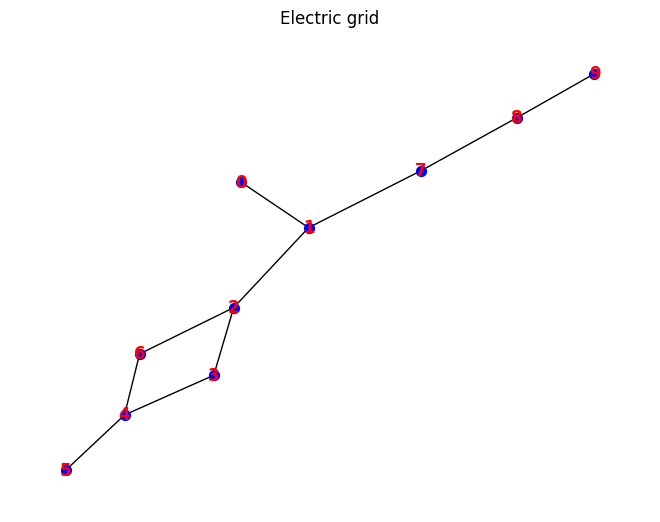

In [13]:
tp.plot_grid(training_data["topology (index)"]['grid_001'])

In [ ]:
def fetch_test_topology_data(difficulty: str = "clean") -> dict:
    """
    Call GET /topology-data and return the nested JSON as Python dict.
    """
    url = f"{BASE_URL}{TOPOLOGY_PREFIX}/topology-data"
    resp = requests.get(url, params={"difficulty": difficulty})
    return check_response(resp)

In [ ]:
test_data = fetch_test_topology_data(difficulty="clean")

## 1.3 Building a guess payload

To submit a topology discovery guess to the benchmark, we must send a JSON object with the following structure:

- `guess_id` – An arbitrary identifier chosen by you (e.g. `"tutorial_guess"`).  
- `grid_id` – The grid to which this guess applies (here, `"grid_001"`).  
- `guesses` – A list of connections `[node_i, node:j]`, where:
  - `node_i` is the parent node.
  - `node_j` is the child node.

In this notebook we:

- Extract the list of nodes from the test dataset.
- Assign each node a random parent.
- Store the result in the `guess` dictionary, ready to be sent to the API.

In [33]:
guess = {"guess_id" : "tutorial_guess", "grid_id" : "grid_001", "guesses": []}
node_list = [node for node in test_data["grids"]["grid_001"]]

for i_node, node in enumerate(node_list):
    guess["guesses"].append([i_node, int(np.random.uniform(len(node_list)))])

In [34]:
guess

{'guess_id': 'tutorial_guess',
 'grid_id': 'grid_001',
 'guesses': [[0, 9],
  [1, 7],
  [2, 5],
  [3, 9],
  [4, 2],
  [5, 5],
  [6, 4],
  [7, 3],
  [8, 8],
  [9, 2]]}

## 1.4 Submitting the guess to the API

Once we have our `guess` object, we need to send it to the **submission endpoint**:

**Endpoint:**  
`POST {TOPOLOGY_PREFIX}/submit-results`

which:
- Validates the format of the payload.
- Registers the guess under the provided `guess_id`.
- Returns a confirmation status.

If the submission is accepted, we can later **request a score** for this `guess_id` and `grid_id`.  
If it fails, the error message returned here is usually the best place to troubleshoot the JSON structure.

In [35]:
def submit_topology_data_guesses(guess) -> dict:
    """
    Call POST /submit-estimates and return the success message.
    """
    
    url = f"{BASE_URL}{TOPOLOGY_PREFIX}/submit-results"
    resp = requests.post(url, json = guess)
    return check_response(resp)

In [36]:
submit_topology_data_guesses(guess)

{'status': 'submitted'}

## 1.5 Requesting a score for the guess

**Endpoint:**  
`GET {TOPOLOGY_PREFIX}/score?guess_id=...&grid_id=...`

This endpoint:

- Looks up the stored guess identified by `guess_id` and `grid_id`.
- resolves anonymised grid IDs
- Compares it against the **hidden ground truth** for the test data.
- Returns one or more **metrics** (for example, accuracy per node or overall accuracy).

In this tutorial we:

- Request the score for the random `tutorial_guess`.
- Inspect the raw response and discuss how you might log or visualise these metrics when using a real model.

In [39]:
def fetch_topology_score(guess_id: str,
                      grid_id: str):
    """
    Fetch the topology discovery score for a given guess_id and grid_id.

    Relies on global BASE_URL and TOPOLOGY_PREFIX variables.
    Returns the raw `requests.Response` object.
    """
    url = f"{BASE_URL}{TOPOLOGY_PREFIX}/score"
    payload = {"guess_id": guess_id, "grid_id": grid_id}
    resp = requests.get(url, params=payload)
    return resp.text

In [40]:
fetch_topology_score("tutorial_guess", "grid_001")

'{"guess_id":"tutorial_guess","grid_id":"grid_001","total_true_edges":10,"guessed_edges":10,"correct":2,"incorrect_extra":8,"missed":8,"accuracy":0.2}'

## 2. Topology Discovery: UI Usage

The web interface provides a point-and-click version of the benchmark workflow, mirroring the API calls shown earlier. You can use it to run the full topology discovery pipeline without writing any code.

1. **Open the Topology Discovery page**

   From the application UI, open **Topology Discovery**.

   On the page you will see three sections:
   - **Download Data**
   - **Submit Topology Guesses**
   - **Check Score**

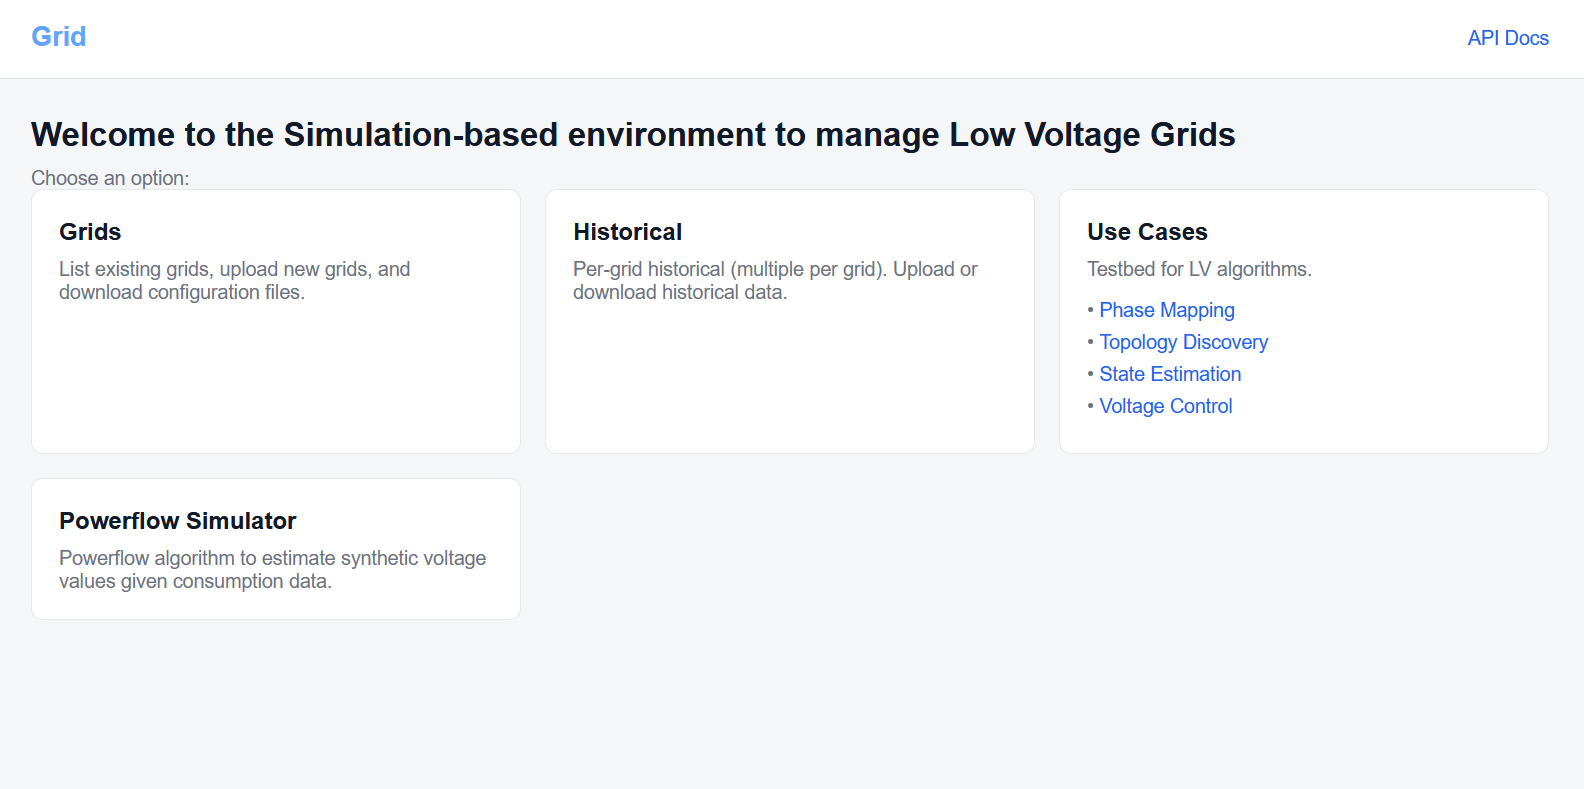

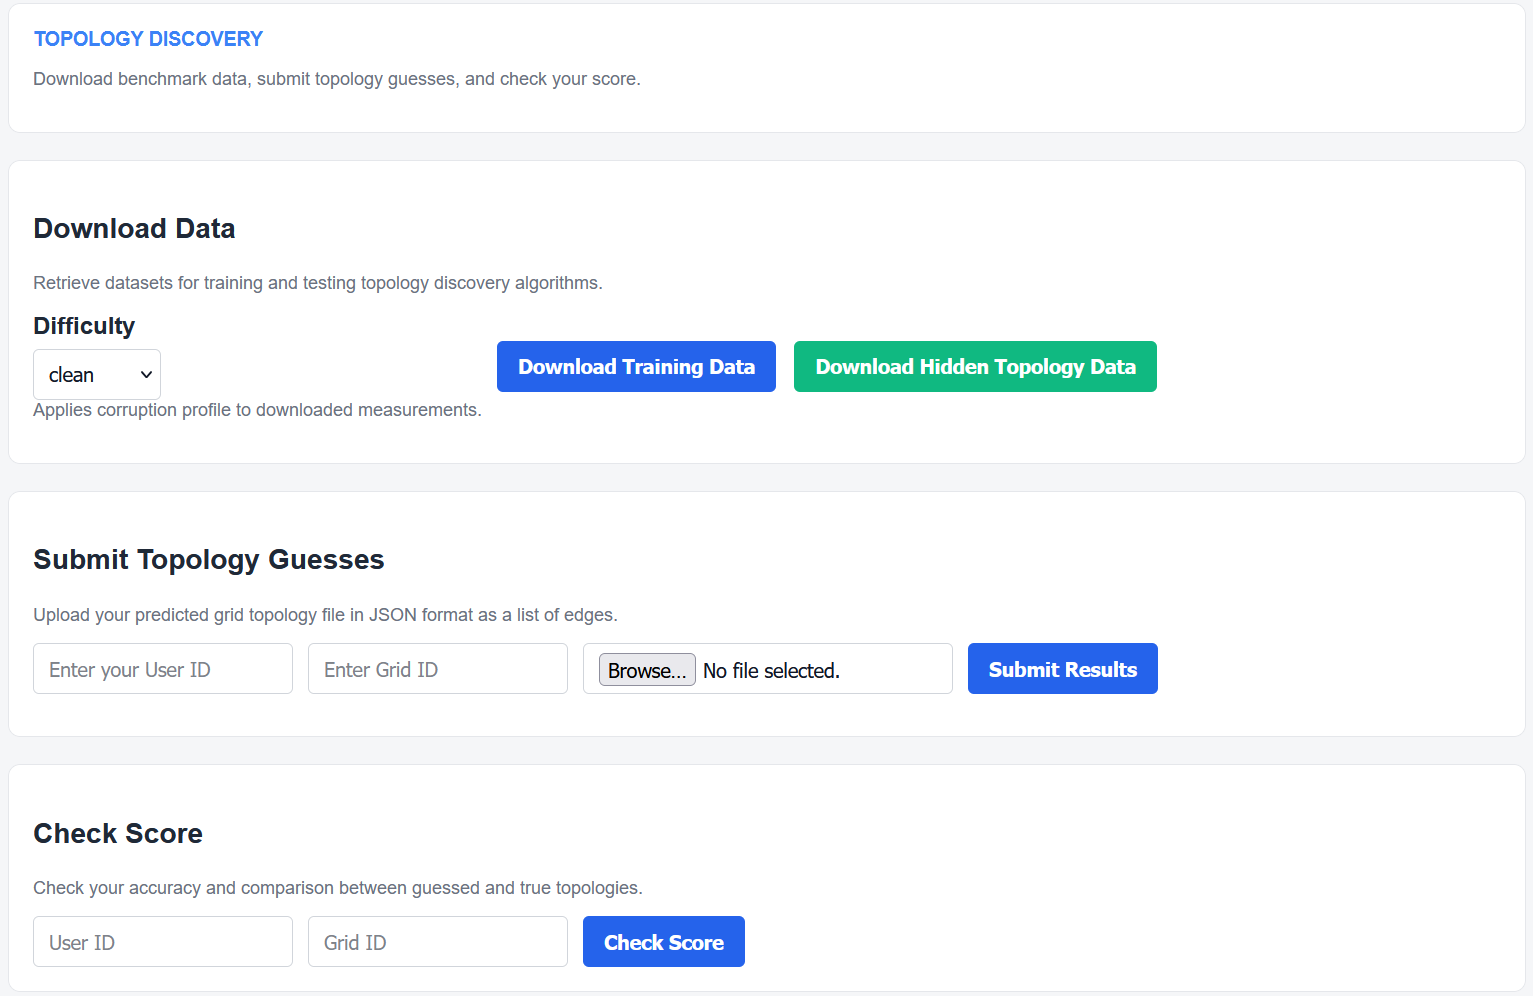

2. **Download data**

   In the **Download Data** section you can:
   - Choose a **Difficulty**: `clean`, `easy`, `medium`, or `hard`
   - Click **Download Training Data** to get a ZIP/JSON file with measurements and *known* topology.
   - Click **Download Hidden Topology Data** to get the corresponding test dataset *without* topology information.

   These files are what you will feed into your own algorithm or model.

   Notes:
   - training data includes the true topology and index mappings
   - test data hides the topology target
   - test grids are identified by anonymised grid IDs
   - `difficulty` changes the corruption profile applied to measurement values

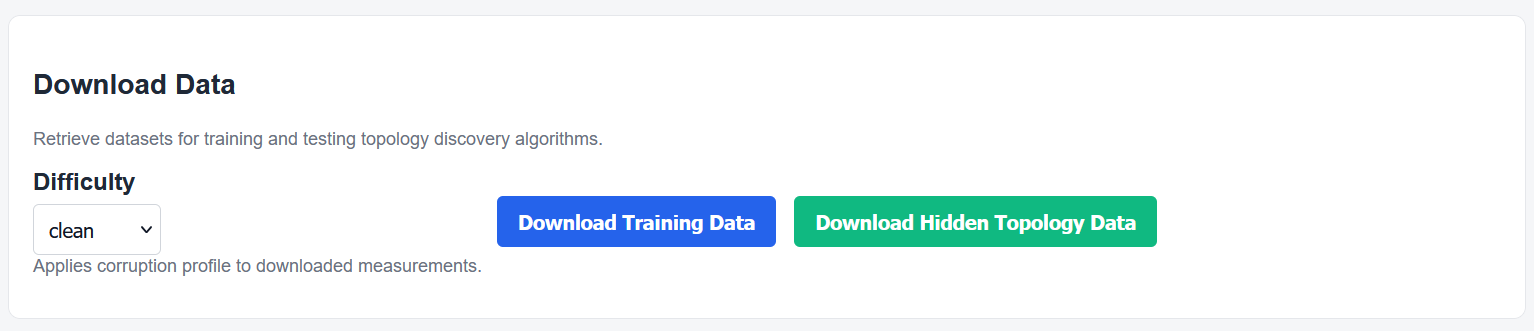

3. **Submit topology guesses**

   After your algorithm has produced a topology candidate, package the results in the required JSON/ZIP format (as described in the documentation) and upload it in the **Submit Topology Guesses** section:
   - **User ID** is a free text label you choose (e.g. `baseline_model`, `gnn_v2`).
   - enter a **Grid ID**
   - Use the file picker to select your guesses file and click **Submit Guesses**.  
   If the format is valid, the UI will confirm that the submission was accepted.

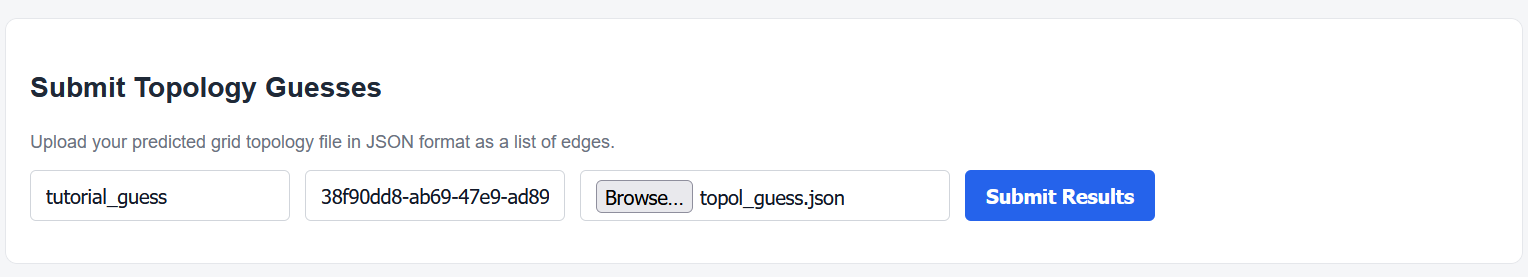

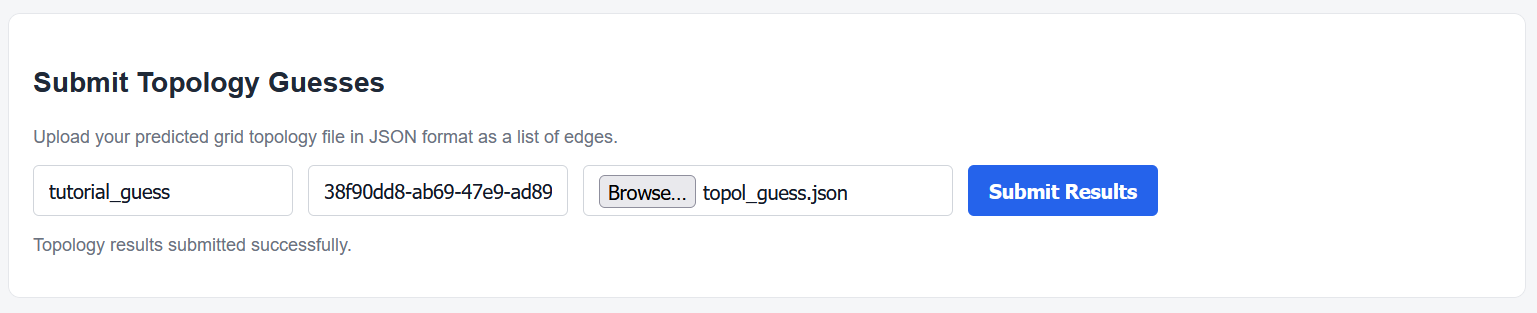

4. **Check score**

   Once a guess has been submitted, you can evaluate it in the **Check Score** section:
   - Enter the same **User ID** and **Grid ID** you used when submitting.
   - Click **Check Score** to request the evaluation.
   - The UI will display the resulting metric(s), which you can compare across different models or runs.

You can repeat the *submit → score* cycle as many times as you like, using different models or hyper-parameters, while keeping the same downloaded datasets. This makes it easy to treat the interface as a lightweight leaderboard for your topology discovery experiments.

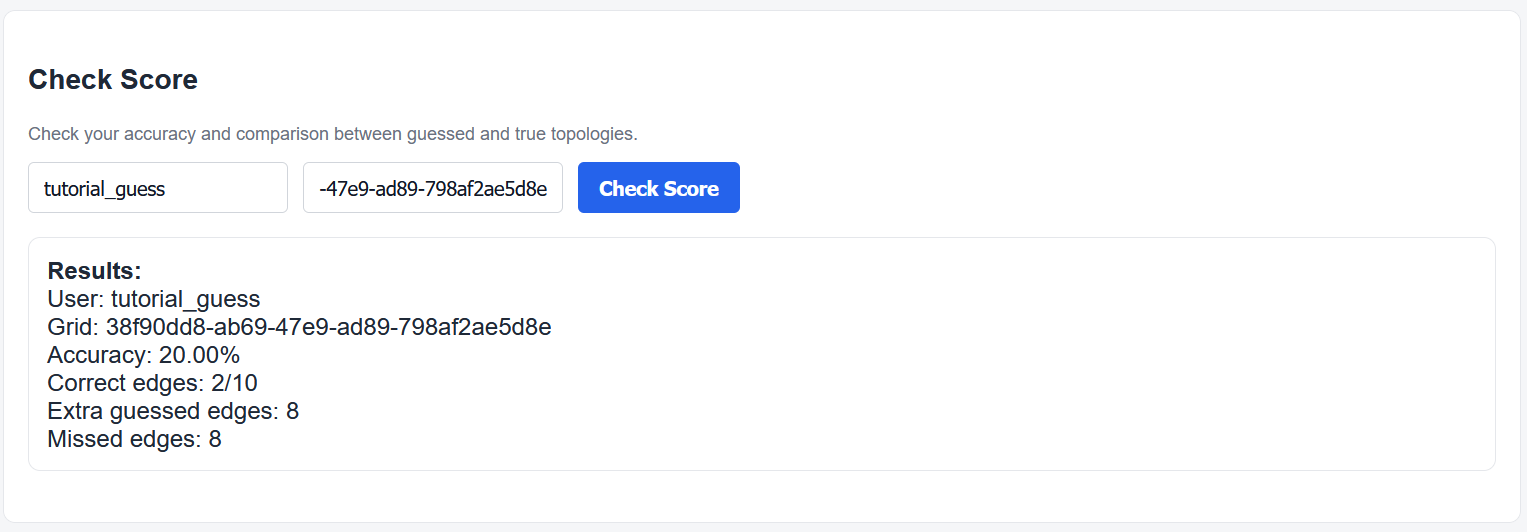